# STUDD on Covtype using CapyMOA

This notebook evaluates whether the STUDD mechanism can produce a useful unsupervised drift signal on the Covtype data stream, using Page-Hinkley to generate alarms.

At this stage, no adaptation is performed after a detected drift.  
The goal is only to check whether the teacher-student disagreement behaves as a meaningful mimicking-loss signal.

The teacher is trained once on an initial reference window of size `W = 2000` and then remains fixed during the monitoring phase.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.datasets import Covtype
from capymoa.drift.detectors import STUDD, PageHinkley

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
    collect_instances,
)

configure_matplotlib()

## Configuration

We define the STUDD parameters and model choices.

In [2]:
W = 2000
N_TREES = 100
PH_DELTA = 0.001
SEED = 1

TEACHER_TYPE = "lr"
STUDENT_TYPE = "lr"

window = 200

## Load data stream

In [3]:
stream = Covtype()

print(stream.get_schema())

@relation covtype-raw

@attribute Elevation numeric
@attribute Aspect numeric
@attribute Slope numeric
@attribute Horizontal_Distance_To_Hydrology numeric
@attribute Vertical_Distance_To_Hydrology numeric
@attribute Horizontal_Distance_To_Roadways numeric
@attribute Hillshade_9am numeric
@attribute Hillshade_Noon numeric
@attribute Hillshade_3pm numeric
@attribute Horizontal_Distance_To_Fire_Points numeric
@attribute Wilderness_Area1 {0,1}
@attribute Wilderness_Area2 {0,1}
@attribute Wilderness_Area3 {0,1}
@attribute Wilderness_Area4 {0,1}
@attribute Soil_Type1 {0,1}
@attribute Soil_Type2 {0,1}
@attribute Soil_Type3 {0,1}
@attribute Soil_Type4 {0,1}
@attribute Soil_Type5 {0,1}
@attribute Soil_Type6 {0,1}
@attribute Soil_Type7 {0,1}
@attribute Soil_Type8 {0,1}
@attribute Soil_Type9 {0,1}
@attribute Soil_Type10 {0,1}
@attribute Soil_Type11 {0,1}
@attribute Soil_Type12 {0,1}
@attribute Soil_Type13 {0,1}
@attribute Soil_Type14 {0,1}
@attribute Soil_Type15 {0,1}
@attribute Soil_Type16 {0,1}

## Create teacher, student and STUDD detector

The teacher is the main predictive model.  
The student is used internally by STUDD to mimic the teacher's predictions.
The Page-Hinkley detector receives the mimicking-loss signal produced by STUDD.

In [4]:
teacher = make_teacher(
    schema=stream.get_schema(),
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

student = make_student(
    schema=stream.get_schema(),
    student_type=STUDENT_TYPE,
    seed=SEED + 1,
    n_trees=N_TREES,
)

studd = STUDD(
    student=student,
    min_n_instances=W,
    detector=PageHinkley(delta=PH_DELTA)
)

## Monitoring phase without adaptation

During monitoring:

- the teacher predicts each new instance
- STUDD receives the instance and the teacher prediction
- STUDD updates its internal student model
- STUDD monitors the teacher-student agreement signal
- the teacher is not updated
- no adaptation is performed after alarms

The true labels are used only for evaluation, not for drift detection.

In [5]:
# Offline teacher training
initial_batch = collect_instances(stream, W)

for inst in initial_batch:
    teacher.train(inst)

print(f"Teacher trained on initial batch: {len(initial_batch)} instances")


# Monitoring phase
records = []
studd_drift_points = []

processed = W

while stream.has_more_instances():

    inst = stream.next_instance()

    y_true = inst.y_index
    y_teacher = teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)

    studd.add_element(inst, y_teacher)

    detected_change = studd.detected_change()

    if detected_change:
        studd_drift_points.append(processed)

    records.append({
        "t": processed,
        "y_true": y_true,
        "y_teacher": y_teacher,
        "teacher_correct": teacher_correct,
        "drift_alarm": detected_change,
    })

    processed += 1

results = pd.DataFrame(records)

print(f"Monitoring instances processed: {len(results)}")
print(f"Number of detected drift alarms: {len(studd_drift_points)}")
print(f"First 10 drift points: {studd_drift_points[:10]}")

Teacher trained on initial batch: 2000 instances
Monitoring instances processed: 579012
Number of detected drift alarms: 2
First 10 drift points: [10809, 15776]


## Extract STUDD agreement signal

The STUDD detector stores its agreement signal internally.

Because STUDD requires `min_n_instances` before producing the signal, we align the signal with the correct stream indices using an offset.

In [6]:
agreement = np.array(studd.data, dtype=float)
disagreement = 1.0 - agreement

agreement_offset = studd.min_n_instances

agreement_t = np.arange(
    agreement_offset,
    agreement_offset + len(agreement)
)

agreement_df = pd.DataFrame({
    "t": agreement_t,
    "agreement": agreement,
    "disagreement": disagreement,
})

agreement_df.head()

,t,agreement,disagreement
0,2000,1.0,0.0
1,2001,1.0,0.0
2,2002,1.0,0.0
3,2003,1.0,0.0
4,2004,1.0,0.0


## Summary metrics

We summarize the monitoring run using teacher accuracy, average agreement, average disagreement and the detected drift alarms.

In [7]:
summary = {
    "W": W,
    "teacher": TEACHER_TYPE,
    "student": STUDENT_TYPE,
    "monitoring_instances": len(results),
    "teacher_accuracy": results["teacher_correct"].mean(),
    "mean_agreement": agreement_df["agreement"].mean(),
    "mean_disagreement": agreement_df["disagreement"].mean(),
    "num_alarms": len(studd_drift_points),
    "first_alarm": studd_drift_points[0] if studd_drift_points else None,
}

summary_df = pd.DataFrame([summary])
summary_df

,W,teacher,student,monitoring_instances,teacher_accuracy,mean_agreement,mean_disagreement,num_alarms,first_alarm
0,2000,lr,lr,579012,0.072551,0.985473,0.014527,2,10809


## Rolling metrics

We compute rolling averages for:

- teacher accuracy
- STUDD agreement
- STUDD disagreement

Rolling averages make the temporal behavior easier to inspect visually.

In [8]:
roll_acc_values, _ = rolling_mean(
    results["teacher_correct"].to_numpy(dtype=float),
    window,
)

rolling_accuracy_df = pd.DataFrame({
    "t": results["t"].to_numpy()[window - 1:],
    "rolling_teacher_accuracy": roll_acc_values,
})

roll_agreement_values, _ = rolling_mean(
    agreement_df["agreement"].to_numpy(dtype=float),
    window,
)

roll_disagreement_values, _ = rolling_mean(
    agreement_df["disagreement"].to_numpy(dtype=float),
    window,
)

rolling_studd_df = pd.DataFrame({
    "t": agreement_df["t"].to_numpy()[window - 1:],
    "rolling_agreement": roll_agreement_values,
    "rolling_disagreement": roll_disagreement_values,
})

## Plot rolling teacher accuracy

This plot shows how the static teacher performs over time.

Detected STUDD alarms are shown as vertical red lines.

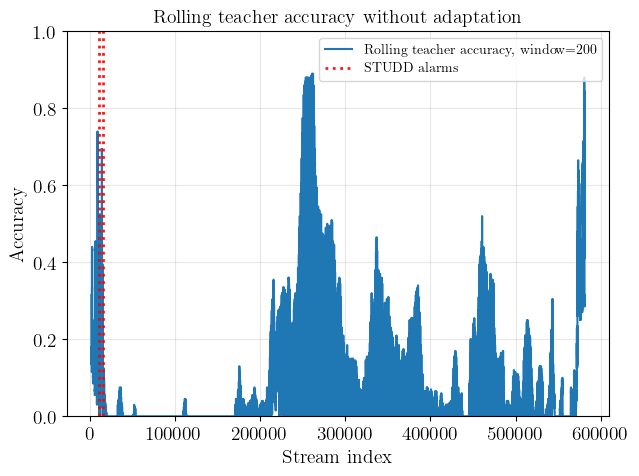

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_accuracy_df["t"],
    rolling_accuracy_df["rolling_teacher_accuracy"],
    label=f"Rolling teacher accuracy, window={window}",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        alpha=0.9,
        linewidth=2.0,
        linestyle=":",
        label="STUDD alarms" if i == 0 else None,
    )

plt.title("Rolling teacher accuracy without adaptation")
plt.xlabel("Stream index")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Plot STUDD agreement signal

This plot shows the rolling agreement between the teacher and the student.

A drop in agreement means that the student is no longer mimicking the teacher as well as before.

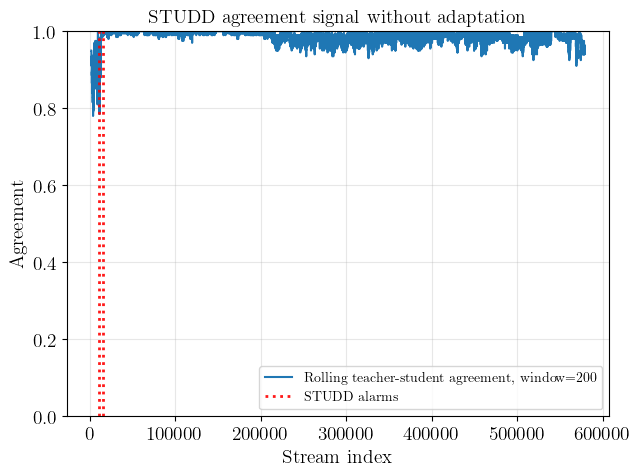

In [10]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_agreement"],
    label=f"Rolling teacher-student agreement, window={window}",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        alpha=0.9,
        linewidth=2.0,
        linestyle=":",
        label="STUDD alarms" if i == 0 else None,
    )

plt.title("STUDD agreement signal without adaptation")
plt.xlabel("Stream index")
plt.ylabel("Agreement")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Plot STUDD mimicking loss

This plot shows the teacher-student disagreement, which is the mimicking-loss signal monitored by STUDD.

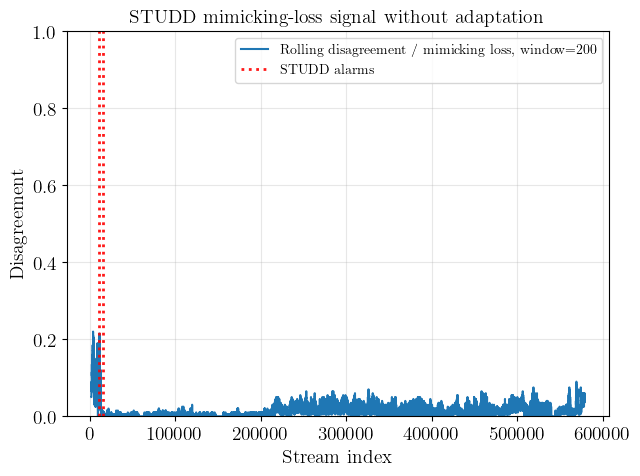

In [11]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_disagreement"],
    label=f"Rolling disagreement / mimicking loss, window={window}",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        alpha=0.9,
        linewidth=2.0,
        linestyle=":",
        label="STUDD alarms" if i == 0 else None,
    )

plt.title("STUDD mimicking-loss signal without adaptation")
plt.xlabel("Stream index")
plt.ylabel("Disagreement")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Combined plot

This plot compares teacher accuracy and STUDD disagreement.

A useful STUDD signal should change when the relationship between teacher and student becomes unstable.

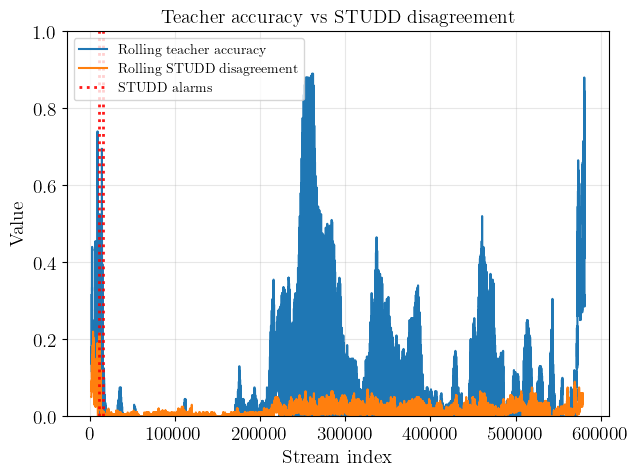

In [12]:
plt.figure(figsize=(7, 5))

plt.plot(
    rolling_accuracy_df["t"],
    rolling_accuracy_df["rolling_teacher_accuracy"],
    label="Rolling teacher accuracy",
)

plt.plot(
    rolling_studd_df["t"],
    rolling_studd_df["rolling_disagreement"],
    label="Rolling STUDD disagreement",
)

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        alpha=0.9,
        linewidth=2.0,
        linestyle=":",
        label="STUDD alarms" if i == 0 else None,
    )

plt.title("Teacher accuracy vs STUDD disagreement")
plt.xlabel("Stream index")
plt.ylabel("Value")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Focused view around the detected alarms

This plot compares:

- rolling teacher accuracy
- rolling STUDD disagreement
- all detected STUDD alarms inside the selected interval

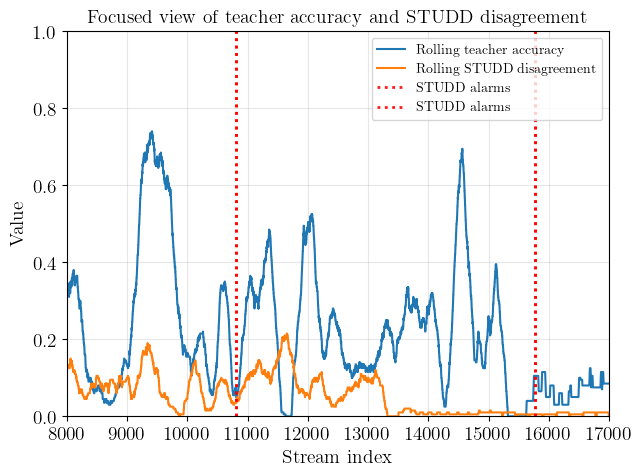

STUDD alarms in focused interval [8000, 17000]: [10809, 15776]


In [13]:
FOCUS_START = 8_000
FOCUS_END = 17_000

accuracy_focus = rolling_accuracy_df[
    (rolling_accuracy_df["t"] >= FOCUS_START) &
    (rolling_accuracy_df["t"] <= FOCUS_END)
]

studd_focus = rolling_studd_df[
    (rolling_studd_df["t"] >= FOCUS_START) &
    (rolling_studd_df["t"] <= FOCUS_END)
]

alarms_focus = [
    dp for dp in studd_drift_points
    if FOCUS_START <= dp <= FOCUS_END
]

plt.figure(figsize=(7, 5))

plt.plot(
    accuracy_focus["t"],
    accuracy_focus["rolling_teacher_accuracy"],
    label="Rolling teacher accuracy",
)

plt.plot(
    studd_focus["t"],
    studd_focus["rolling_disagreement"],
    label="Rolling STUDD disagreement",
)

for i, dp in enumerate(alarms_focus):
    plt.axvline(
        dp,
        color="red",
        linestyle=":",
        linewidth=2,
        alpha=0.9,
        label="STUDD alarms" if i == 0 else None,
    )

for i, dp in enumerate(studd_drift_points):
    plt.axvline(
        dp,
        color="red",
        alpha=0.9,
        linewidth=2.0,
        linestyle=":",
        label="STUDD alarms" if i == 0 else None,
    )

plt.title(
    "Focused view of teacher accuracy and STUDD disagreement"
)
plt.xlabel("Stream index")
plt.ylabel("Value")
plt.xlim(FOCUS_START, FOCUS_END)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"STUDD alarms in focused interval [{FOCUS_START}, {FOCUS_END}]: {alarms_focus}")

## Local zoom plots around each STUDD alarm

Here, we generate one local plot for each STUDD alarm.  
Each plot focuses on a symmetric interval around the alarm:

- `1000` instances before the alarm
- `1000` instances after the alarm

This allows us to inspect whether teacher accuracy and STUDD disagreement change locally around each detected alarm.

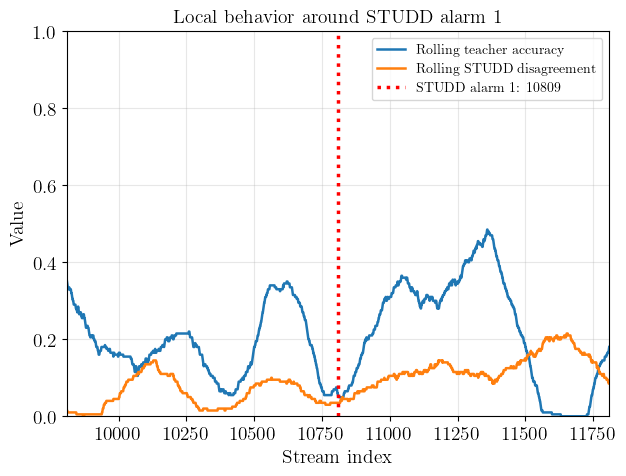

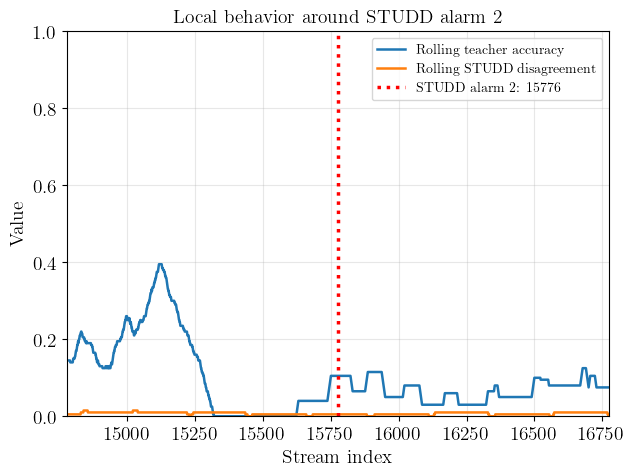

In [14]:
LOCAL_WINDOW = 1_000

for alarm_id, alarm_t in enumerate(studd_drift_points, start=1):

    local_start = max(0, alarm_t - LOCAL_WINDOW)
    local_end = alarm_t + LOCAL_WINDOW

    local_accuracy = rolling_accuracy_df[
        (rolling_accuracy_df["t"] >= local_start) &
        (rolling_accuracy_df["t"] <= local_end)
    ]

    local_studd = rolling_studd_df[
        (rolling_studd_df["t"] >= local_start) &
        (rolling_studd_df["t"] <= local_end)
    ]

    plt.figure(figsize=(7, 5))

    plt.plot(
        local_accuracy["t"],
        local_accuracy["rolling_teacher_accuracy"],
        label="Rolling teacher accuracy",
        linewidth=1.8,
    )

    plt.plot(
        local_studd["t"],
        local_studd["rolling_disagreement"],
        label="Rolling STUDD disagreement",
        linewidth=1.8,
    )

    plt.axvline(
        alarm_t,
        color="red",
        linestyle=":",
        linewidth=2.5,
        label=f"STUDD alarm {alarm_id}: {alarm_t}",
    )

    plt.title(
        f"Local behavior around STUDD alarm {alarm_id}"
    )
    plt.xlabel("Stream index")
    plt.ylabel("Value")
    plt.xlim(local_start, local_end)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()